In [2]:
import pandas as pd
df = pd.read_csv("personal_finance_tracker_dataset.csv")
print(df.head())

         date  user_id  monthly_income  monthly_expense_total  savings_rate  \
0  2019-01-01     1584         3119.58                3212.07          0.38   
1  2019-01-31     1045         3262.44                3732.81          0.10   
2  2019-03-02     1756         2931.20                3335.58          0.15   
3  2019-04-01     1724         3506.79                2327.59          0.17   
4  2019-05-01     1600         4606.87                2182.58          0.34   

   budget_goal financial_scenario  credit_score  debt_to_income_ratio  \
0      3676.11          inflation         721.0                  0.56   
1      2607.17          inflation         670.0                  0.42   
2      3004.14          inflation         691.0                  0.24   
3      3346.97             normal         717.0                  0.16   
4      2670.09          inflation         795.0                  0.25   

   loan_payment  ...  discretionary_spending  essential_spending  income_type  \
0    

In [3]:
df.isnull().sum()

date                      0
user_id                   0
monthly_income            0
monthly_expense_total     0
savings_rate              0
budget_goal               0
financial_scenario        0
credit_score              0
debt_to_income_ratio      0
loan_payment              0
investment_amount         0
subscription_services     0
emergency_fund            0
transaction_count         0
fraud_flag                0
discretionary_spending    0
essential_spending        0
income_type               0
rent_or_mortgage          0
category                  0
cash_flow_status          0
financial_advice_score    0
financial_stress_level    0
actual_savings            0
savings_goal_met          0
dtype: int64

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    3000 non-null   object 
 1   user_id                 3000 non-null   int64  
 2   monthly_income          3000 non-null   float64
 3   monthly_expense_total   3000 non-null   float64
 4   savings_rate            3000 non-null   float64
 5   budget_goal             3000 non-null   float64
 6   financial_scenario      3000 non-null   object 
 7   credit_score            3000 non-null   float64
 8   debt_to_income_ratio    3000 non-null   float64
 9   loan_payment            3000 non-null   float64
 10  investment_amount       3000 non-null   float64
 11  subscription_services   3000 non-null   int64  
 12  emergency_fund          3000 non-null   float64
 13  transaction_count       3000 non-null   int64  
 14  fraud_flag              3000 non-null   

In [5]:
df = df.drop(columns=['date', 'user_id'])

In [6]:
df['financial_scenario'] = df['financial_scenario'].map({
    'normal': 0,
    'inflation': 1,
    'recession': 2
})

from sklearn.preprocessing import LabelEncoder

income_encoder = LabelEncoder()
category_encoder = LabelEncoder()
cashflow_encoder = LabelEncoder()

df["income_type"] = income_encoder.fit_transform(df["income_type"])
df["category"] = category_encoder.fit_transform(df["category"])
df["cash_flow_status"] = cashflow_encoder.fit_transform(df["cash_flow_status"])

In [7]:
# Expense to income ratio (very important)
df['expense_income_ratio'] = df['monthly_expense_total'] / df['monthly_income']

# Savings amount (optional but good)
df['savings_amount'] = df['monthly_income'] * df['savings_rate']

In [8]:
def classify_risk(row):
    score = 0

    # Expense pressure
    if row['expense_income_ratio'] > 1:
        score += 2

    # Savings behavior
    if row['savings_rate'] < 0.1:
        score += 2
    elif row['savings_rate'] < 0.2:
        score += 1

    # Debt burden
    if row['debt_to_income_ratio'] > 0.4:
        score += 2
    elif row['debt_to_income_ratio'] > 0.3:
        score += 1

    # Credit score
    if row['credit_score'] < 600:
        score += 2
    elif row['credit_score'] < 700:
        score += 1

    # Emergency fund
    if row['emergency_fund'] < 1000:
        score += 1

    # Final classification
    if score <= 2:
        return 0   # Low Risk
    elif score <= 5:
        return 1   # Medium Risk
    else:
        return 2   # High Risk

df['risk'] = df.apply(classify_risk, axis=1)

In [18]:
X = df.drop(columns=['risk'])
y = df['risk']

stress_map = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}

X['financial_stress_level'] = X['financial_stress_level'].map(stress_map)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
print(X.columns.tolist())
print(len(X.columns))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

['monthly_income', 'monthly_expense_total', 'savings_rate', 'budget_goal', 'financial_scenario', 'credit_score', 'debt_to_income_ratio', 'loan_payment', 'investment_amount', 'subscription_services', 'emergency_fund', 'transaction_count', 'fraud_flag', 'discretionary_spending', 'essential_spending', 'income_type', 'rent_or_mortgage', 'category', 'cash_flow_status', 'financial_advice_score', 'financial_stress_level', 'actual_savings', 'savings_goal_met', 'expense_income_ratio', 'savings_amount']
25


In [28]:
print(X_train.dtypes)

monthly_income            float64
monthly_expense_total     float64
savings_rate              float64
budget_goal               float64
financial_scenario          int64
credit_score              float64
debt_to_income_ratio      float64
loan_payment              float64
investment_amount         float64
subscription_services       int64
emergency_fund            float64
transaction_count           int64
fraud_flag                  int64
discretionary_spending    float64
essential_spending        float64
income_type                 int64
rent_or_mortgage          float64
category                    int64
cash_flow_status            int64
financial_advice_score    float64
financial_stress_level     object
actual_savings            float64
savings_goal_met            int64
expense_income_ratio      float64
savings_amount            float64
dtype: object


In [22]:
for col in X.columns:
    if X[col].dtype == 'object':
        print(col, X[col].unique())

In [23]:
print(X.dtypes)

monthly_income            float64
monthly_expense_total     float64
savings_rate              float64
budget_goal               float64
financial_scenario          int64
credit_score              float64
debt_to_income_ratio      float64
loan_payment              float64
investment_amount         float64
subscription_services       int64
emergency_fund            float64
transaction_count           int64
fraud_flag                  int64
discretionary_spending    float64
essential_spending        float64
income_type                 int64
rent_or_mortgage          float64
category                    int64
cash_flow_status            int64
financial_advice_score    float64
financial_stress_level      int64
actual_savings            float64
savings_goal_met            int64
expense_income_ratio      float64
savings_amount            float64
dtype: object


In [24]:
print(df["cash_flow_status"].unique())

[2 0 1]


In [25]:
X = df.drop(columns=['risk'])
y = df['risk']

In [29]:
stress_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

X["financial_stress_level"] = X["financial_stress_level"].map(stress_map)

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [35]:
y_pred = model.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9383333333333334
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       213
           1       0.92      0.98      0.95       350
           2       0.92      0.62      0.74        37

    accuracy                           0.94       600
   macro avg       0.94      0.84      0.88       600
weighted avg       0.94      0.94      0.94       600



In [37]:
from sklearn.linear_model import LogisticRegression

print(LogisticRegression)

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [39]:
from sklearn.metrics import accuracy_score

In [81]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest:",
      accuracy_score(y_test, rf_pred))

Random Forest: 0.9466666666666667


In [82]:
import pickle

pickle.dump(model, open("best_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [83]:
import pickle

with open("best_model.pkl", "wb") as file:
    pickle.dump(rf, file)

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Saved successfully!")

Saved successfully!


In [84]:
print(X.columns.tolist())

['monthly_income', 'monthly_expense_total', 'savings_rate', 'budget_goal', 'financial_scenario', 'credit_score', 'debt_to_income_ratio', 'loan_payment', 'investment_amount', 'subscription_services', 'emergency_fund', 'transaction_count', 'fraud_flag', 'discretionary_spending', 'essential_spending', 'income_type', 'rent_or_mortgage', 'category', 'cash_flow_status', 'financial_advice_score', 'actual_savings', 'savings_goal_met', 'expense_income_ratio', 'savings_amount']


In [85]:
print("Income Type")
print(df["income_type"].astype("category").cat.categories)

print("\nCategory")
print(df["category"].astype("category").cat.categories)

print("\nCash Flow Status")
print(df["cash_flow_status"].astype("category").cat.categories)

Income Type
Index([0, 1, 2], dtype='int64')

Category
Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype='int64')

Cash Flow Status
Index([0], dtype='int64')


In [86]:
print(X.shape)

(3000, 24)


In [87]:
import pickle

pickle.dump(income_encoder, open("income_encoder.pkl", "wb"))
pickle.dump(category_encoder, open("category_encoder.pkl", "wb"))
pickle.dump(cashflow_encoder, open("cashflow_encoder.pkl", "wb"))

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.82      0.72      0.77       213
           1       0.80      0.87      0.84       350
           2       0.65      0.59      0.62        37

    accuracy                           0.80       600
   macro avg       0.76      0.73      0.74       600
weighted avg       0.80      0.80      0.80       600

[[154  59   0]
 [ 34 304  12]
 [  0  15  22]]


In [41]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.8633333333333333
              precision    recall  f1-score   support

           0       0.92      0.80      0.86       213
           1       0.87      0.90      0.89       350
           2       0.62      0.86      0.72        37

    accuracy                           0.86       600
   macro avg       0.80      0.86      0.82       600
weighted avg       0.87      0.86      0.86       600

[[170  43   0]
 [ 14 316  20]
 [  0   5  32]]


In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.9383333333333334
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       213
           1       0.92      0.98      0.95       350
           2       0.92      0.62      0.74        37

    accuracy                           0.94       600
   macro avg       0.94      0.84      0.88       600
weighted avg       0.94      0.94      0.94       600

[[196  17   0]
 [  4 344   2]
 [  0  14  23]]


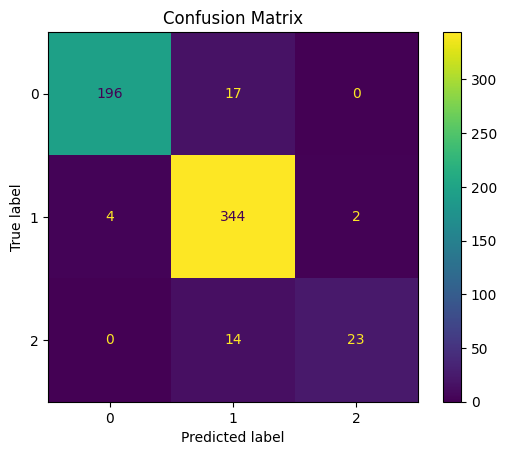

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

plt.title("Confusion Matrix")
plt.show()

In [47]:
import pickle

with open("income_encoder.pkl", "rb") as f:
    encoder = pickle.load(f)

print(encoder.classes_)

[0 1 2]


In [48]:
print(income_encoder.classes_)
print(category_encoder.classes_)
print(cashflow_encoder.classes_)

['Freelance' 'Mixed' 'Salary']
['Dining Out' 'Education' 'Entertainment' 'Groceries' 'Healthcare'
 'Insurance' 'Investments' 'Rent' 'Transportation' 'Utilities']
['Negative' 'Neutral' 'Positive']
